## Introduction

In [1]:
import os

os.environ['MKL_THREADING_LAYER'] = 'GNU'

In [2]:
import hvplot.xarray
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
import json
from copy import deepcopy


In [3]:
experiment_path = Path('../rapid-geostrophic-reconstruction/figs/experiment_20241218_102005/')

# Load the configuration file

config = json.load((experiment_path / 'config.json').open())

dataset_path = Path(config['dataset_path'])
target_reference_level = config['target_reference_level']
ref_folder = f'{abs(target_reference_level)}m_ref'

using_transport_from_previous_year = config['using_transport_from_previous_year']
using_missing_indices = config['using_missing_indices']
use_deep_dvdz = config['use_deep_dvdz']

mean_dv_dz_moorings = np.array(config['mean_dv_dz_moorings'])
std_dv_dz_moorings = np.array(config['std_dv_dz_moorings'])

In [4]:
def load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = None):
    ds_argo_merged = xr.open_dataset(dataset_path / f'../../ds_argo_obs.nc')
    t_umo_obs = xr.open_dataset(dataset_path / ref_folder/ f't_umo_obs.nc')
    ds_pos = xr.open_dataset(dataset_path / ref_folder/ f'ds_pos_obs.nc')
    dv_dz = xr.open_dataset(dataset_path / ref_folder / f'dv_dz_obs_fillup.nc')

    # t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()
    t_umo_obs = t_umo_obs.groupby(t_umo_obs.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    ds_pos = ds_pos.groupby(ds_pos.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})
    dv_dz = dv_dz.groupby(dv_dz.time.dt.floor(time_smoothing)).mean().rename({'floor': 'time'})

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))


    ds_pos = ds_pos.sel(pos = ['west', 'marwest', 'mareast', 'east'])

    return ds_argo_merged, t_umo_obs, ds_pos, dv_dz

In [5]:
# Load the argo_dataset and the ground truth dataset

import xarray as xr
time_smoothing = '10D'

lat_bounds = (25, 27)


ds_argo_merged, t_umo_obs, ds_pos_obs, dv_dz_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)


In [6]:
ds_argo_merged

<xarray.Dataset>
Dimensions:       (time: 653, z: 242, pos: 123)
Coordinates:
  * time          (time) datetime64[ns] 2004-04-02 2004-04-12 ... 2022-02-07
  * z             (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
    pressure      (z) float64 ...
    lon           (time, pos) float64 ...
    lat           (time, pos) float64 ...
    time_1d       (time, pos) datetime64[ns] ...
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 116 117 118 119 120 121 122
Data variables:
    temperature   (time, z, pos) float64 ...
    salinity      (time, z, pos) float64 ...
    profile_mask  (time, pos) float64 ...
    ct            (time, z, pos) float64 ...
    rho           (time, z, pos) float64 ...

## Single Profile Processing

We will load the ds_argo_merged dataset as thre base where each prfoile in the ten day window is present.
THen we will create 4 embedding one for each of the moorings and each profile is assigned by distance to those emebeddings. 
Each profile will create based on the currtent state and its rho values a delta that will be added to the embedding.

In [7]:
ds_argo_merged_10days, t_umo_10days, _, _  = load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = lat_bounds)

compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

ds_argo_merged_sim = xr.open_dataset(dataset_path / 'ds_argo_viking_KFS003-1st_70None.nc' )
depth_boundaries = np.diff(ds_argo_merged_sim.z.values)
depth_boundaries = (depth_boundaries / 2) + ds_argo_merged_sim.z.values[:-1]

grouped_depth_profile = ds_argo_merged_10days.groupby_bins('z', np.concatenate([depth_boundaries, [0.0]])).mean()
ds_argo_merged_10days = grouped_depth_profile.assign_coords(z_bins = ds_argo_merged_sim.z.values[1:]).rename({'z_bins': 'z'}).interpolate_na('z')

ds_argo_merged_10days = ds_argo_merged_10days.transpose('time', 'z', 'pos')


# We only take the first 2000 meters depth
ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)#.fillna(0)

ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [8]:
ds_argo_merged_10days

<xarray.Dataset>
Dimensions:       (time: 653, z: 29, pos: 123)
Coordinates:
  * time          (time) datetime64[ns] 2004-04-02 2004-04-12 ... 2022-02-07
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 116 117 118 119 120 121 122
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lat           (time, pos) float64 27.5 28.54 29.68 26.27 ... nan nan nan nan
    time_1d       (time, pos) datetime64[ns] 2004-04-01 ... 1821-11-19T00:46:...
    lon           (time, pos) float64 -68.64 -34.69 -39.77 ... nan nan nan
Data variables:
    temperature   (time, z, pos) float64 nan nan nan 4.251 ... nan nan nan nan
    salinity      (time, z, pos) float64 nan nan nan 35.07 ... nan nan nan nan
    profile_mask  (time, z, pos) float64 nan nan nan 1.0 nan ... nan nan nan nan
    ct            (time, z, pos) float64 nan nan nan 4.09 ... nan nan nan nan
    rho           (time, z, pos) float64 nan nan nan 1.036e+03 ... nan nan nan

## Data Prep

In [9]:
# Prepare a dataset by 1) splitting the data, 2) scaling the input data 
train_slice_pos = 'start'

train_ratio = .350
val_ratio = .150

# t_umo_10days = t_umo_10days.sel(time = slice(None, '2020-01-01'))
# ds_argo_merged_10days = ds_argo_merged_10days.sel(time = slice(None, '2020-01-01'))

indices = np.arange(t_umo_10days.time.shape[0])
# np.random.shuffle(indices)

if train_slice_pos == 'start':
    train_indices = indices[:int(train_ratio * indices.shape[0])]
    val_indices = indices[int(train_ratio * indices.shape[0]):int((train_ratio + val_ratio) * indices.shape[0])]
    test_indices = indices[int((train_ratio + val_ratio) * indices.shape[0]):]
elif train_slice_pos == 'end':
    train_indices = indices[-int(train_ratio * indices.shape[0]):]
    val_indices = indices[-int((train_ratio + val_ratio) * indices.shape[0]): -int(train_ratio * indices.shape[0])]
    test_indices = indices[:-int((train_ratio + val_ratio) * indices.shape[0])]


rho_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).rho
temperature_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).temperature
salinity_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).salinity
load_std = True
if load_std:
    temperature_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc').temperature
    salinity_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc').salinity
    rho_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho
    std_transport = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc').dv_dz_times_X
else:
    rho_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho
    temperature_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).temperature
    salinity_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).salinity
    std_transport = t_umo_10days.isel(time = train_indices).std('time').dv_dz_times_X




def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

def standardize_temperature(ds_pos, temperature_mean=None, temperature_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["temperature"] = (ds_pos["temperature"] - temperature_mean) / temperature_std
    return ds_pos

def standardize_salinity(ds_pos, salinity_mean=None, salinity_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["salinity"] = (ds_pos["salinity"] - salinity_mean) / salinity_std
    return ds_pos


ds_argo_merged_10days_std = standardize_rho(
    ds_argo_merged_10days,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std = standardize_temperature(
    ds_argo_merged_10days_std,
    temperature_mean=temperature_mean,
    temperature_std=temperature_std,
)

ds_argo_merged_10days_std = standardize_salinity(
    ds_argo_merged_10days_std,
    salinity_mean=salinity_mean,
    salinity_std=salinity_std,
)

ds_argo_merged_10days_std = ds_argo_merged_10days_std.fillna(0)

feature_list = [ds_argo_merged_10days_std.rho]

if config['add_tmp']:
    feature_list.append(ds_argo_merged_10days_std.temperature)
if config['add_sal']:
    feature_list.append(ds_argo_merged_10days_std.salinity)

nn_feature_ds = xr.concat(
    feature_list, dim = 'feature'
).stack(nn_feature = ['feature', 'z'])

train_X_scaled = nn_feature_ds.isel(time = train_indices).values
val_X_scaled = nn_feature_ds.isel(time = val_indices).values
test_X_scaled = nn_feature_ds.isel(time = test_indices).values


train_X_mask = ds_argo_merged_10days.isel(time = train_indices).profile_mask.any('z').fillna(0).astype(bool).values
val_X_mask = ds_argo_merged_10days.isel(time = val_indices).profile_mask.any('z').fillna(0).astype(bool).values
test_X_mask = ds_argo_merged_10days.isel(time = test_indices).profile_mask.any('z').fillna(0).astype(bool).values

train_X_lon = ds_argo_merged_10days.isel(time = train_indices).lon.values
val_X_lon = ds_argo_merged_10days.isel(time = val_indices).lon.values
test_X_lon = ds_argo_merged_10days.isel(time = test_indices).lon.values

train_X_lat = ds_argo_merged_10days.isel(time = train_indices).lat.values
val_X_lat = ds_argo_merged_10days.isel(time = val_indices).lat.values
test_X_lat = ds_argo_merged_10days.isel(time = test_indices).lat.values

offset_days = (
    (
        ds_argo_merged_10days.time_1d -
        ds_argo_merged_10days.time
    )
    .fillna(0).dt.days 
)

train_X_days = offset_days.isel(time = train_indices).values
val_X_days = offset_days.isel(time = val_indices).values
test_X_days = offset_days.isel(time = test_indices).values




train_y = t_umo_10days.isel(time = train_indices).dv_dz_times_X
val_y = t_umo_10days.isel(time = val_indices).dv_dz_times_X
test_y = t_umo_10days.isel(time = test_indices).dv_dz_times_X

train_y_prev = t_umo_10days.isel(
    time = xr.DataArray(train_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values
val_y_prev = t_umo_10days.isel(
    time = xr.DataArray(val_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values
test_y_prev = t_umo_10days.isel(
    time = xr.DataArray(test_indices.reshape(-1, 1) - (np.arange(3) + 1).reshape(1,-1))
).dv_dz_times_X.values

mean_transport  = train_y.mean('time')

train_y_scaled = (train_y - mean_transport) / std_transport
val_y_scaled = (val_y - mean_transport) / std_transport
test_y_scaled = (test_y - mean_transport) / std_transport

train_y_prev_scaled = (train_y_prev - mean_transport.values) / std_transport.values
val_y_prev_scaled = (val_y_prev - mean_transport.values) / std_transport.values
test_y_prev_scaled = (test_y_prev - mean_transport.values) / std_transport.values

train_y_scaled = train_y_scaled.fillna(0).values
val_y_scaled = val_y_scaled.fillna(0).values
test_y_scaled = test_y_scaled.fillna(0).values


dv_dz_moorings = dv_dz_obs.sel(time = ds_argo_merged_10days.time).where(dv_dz_obs.z <= -2000, drop = True)

mean_dv_dz_moorings = dv_dz_moorings.mean(['time']).dv_dz_times_X
# mean_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).mean(['time']).dv_dz_times_X
std_dv_dz_moorings = config['std_dv_dz_moorings'] #dv_dz_moorings.std(['time']).dv_dz_times_X
# std_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).std(['time']).dv_dz_times_X

train_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = train_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
val_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = val_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
test_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = test_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values



missing_indices = ds_pos_obs.sel(time = ds_argo_merged_10days .time).temperature.notnull().argmax('z')
missing_indices = xr.where(missing_indices > 0, missing_indices, ds_pos_obs.z.size)
scaled_mis_positions = missing_indices / 10

train_missing_indices = scaled_mis_positions.isel(time = train_indices).values
val_missing_indices = scaled_mis_positions.isel(time = val_indices).values
test_missing_indices = scaled_mis_positions.isel(time = test_indices).values


ds_argo_merged_10days


<xarray.Dataset>
Dimensions:       (time: 653, z: 29, pos: 123)
Coordinates:
  * time          (time) datetime64[ns] 2004-04-02 2004-04-12 ... 2022-02-07
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 116 117 118 119 120 121 122
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lat           (time, pos) float64 27.5 28.54 29.68 26.27 ... nan nan nan nan
    time_1d       (time, pos) datetime64[ns] 2004-04-01 ... 1821-11-19T00:46:...
    lon           (time, pos) float64 -68.64 -34.69 -39.77 ... nan nan nan
Data variables:
    temperature   (time, z, pos) float64 nan nan nan 4.251 ... nan nan nan nan
    salinity      (time, z, pos) float64 nan nan nan 35.07 ... nan nan nan nan
    profile_mask  (time, z, pos) float64 nan nan nan 1.0 nan ... nan nan nan nan
    ct            (time, z, pos) float64 nan nan nan 4.09 ... nan nan nan nan
    rho           (time, z, pos) float64 nan nan nan 1.036e+03 ... nan nan nan

In [10]:
# temperature_std.to_netcdf('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc')
# salinity_std.to_netcdf('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc')
# rho_std.to_netcdf('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc')
# std_transport.to_netcdf('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc')

In [11]:
from torch.utils.data import DataLoader, TensorDataset, Dataset
class ProfileDataset(Dataset):
    def __init__(self, X, y, y_prev, mask, lon, lat, dv_dz, days, compartments, missing_indices):
        self.X = X
        self.y = y
        self.y_prev = y_prev
        self.mask = mask
        self.lon = lon
        self.lat = lat
        self.days = days
        self.compartment = compartments 
        self.dv_dz = dv_dz
        self.missing_indices = missing_indices

        self.len_compartments = len(compartments)

        self.X_per_compartment = []
        self.lon_per_compartment = []
        self.lat_per_compartment = []
        self.dv_dz_per_compartment = []
        self.days_per_compartment = []
        self.missing_indices_per_compartment = []

        self.min_longitude = min([comp[1] for comp in compartments])
        self.max_longitude = max([comp[2] for comp in compartments])



        self.lon_scaled = (self.lon - self.min_longitude) / (self.max_longitude - self.min_longitude)
        self.lat_scaled = (self.lat - lat_bounds[0]) / (lat_bounds[1] - lat_bounds[0])  


        self.days_scaled = self.days / (pd.Timedelta(time_smoothing).days / 2)
        
        for i in range(len(self)):
            mask = self.mask[i]


            compartment_X_per_sample = []
            compartment_lon_per_sample = []
            compartment_lat_per_sample = []
            compartment_days_per_sample = []

            for j in range(self.len_compartments):

                # get all profile indices that are in the compartment and in the mask 
                profile_indices = np.where((self.lon[i] > self.compartment[j][1]) & (self.lon[i] < self.compartment[j][2]) & mask.any(axis = -1))[0]

                if len(profile_indices) < 1:
                    compartment_X_per_sample.append(np.empty(0))
                    compartment_lon_per_sample.append(np.empty(0))
                    compartment_days_per_sample.append(np.empty(0))
                    continue

                lon_compartments = self.lon_scaled[i][profile_indices]
                lat_compartments = self.lat_scaled[i][profile_indices]
                sorted_indices_longitude = lon_compartments.argsort()


                # If I have the sequence -5, -15, 5 the argsort will return [1, 0, 2]
                # As we want to have those profiles as last that are closes to the mooring due to the vanishing gradient 
                # For West moorings the smallest value has to be the last one
                if self.compartment[j][3] == 'west':
                    sorted_indices_longitude = sorted_indices_longitude[::-1]
                
                profile_indices = profile_indices[sorted_indices_longitude]

                compartment_X_per_sample.append(self.X[i][ profile_indices])
                compartment_lon_per_sample.append(self.lon_scaled[i][profile_indices])
                compartment_lat_per_sample.append(self.lat_scaled[i][profile_indices])
                compartment_days_per_sample.append(self.days_scaled[i][profile_indices])
            

            self.X_per_compartment.append(compartment_X_per_sample)
            self.lon_per_compartment.append(compartment_lon_per_sample)
            self.lat_per_compartment.append(compartment_lat_per_sample)
            self.dv_dz_per_compartment.append(self.dv_dz[i])
            self.missing_indices_per_compartment.append(self.missing_indices[i])
            self.days_per_compartment.append(compartment_days_per_sample)


    def __len__(self):
        return self.X.shape[0] 

    def __getitem__(self, idx):

        if using_transport_from_previous_year:
            y_prev = self.y_prev[idx]
        else:
            y_prev = np.zeros_like(self.y_prev[idx])

        if using_missing_indices:
            missing_indices_per_compartment = self.missing_indices_per_compartment[idx] 
        else:
            missing_indices_per_compartment = np.zeros_like(self.missing_indices_per_compartment[idx])
        
        if use_deep_dvdz:
            dv_dz = self.dv_dz_per_compartment[idx]
        else:
            dv_dz = np.zeros_like(self.dv_dz_per_compartment[idx])



        return self.X_per_compartment[idx], self.y[idx], y_prev, self.lon_per_compartment[idx], self.lat_per_compartment[idx], dv_dz, self.days_per_compartment[idx], missing_indices_per_compartment

In [12]:
import torch
train_dataset = ProfileDataset(train_X_scaled, train_y, train_y_prev_scaled, train_X_mask, train_X_lon, train_X_lat, train_dv_dz_moorings_scaled, train_X_days, compartments, train_missing_indices)
val_dataset = ProfileDataset(val_X_scaled, val_y, val_y_prev_scaled, val_X_mask, val_X_lon, val_X_lat, val_dv_dz_moorings_scaled, val_X_days, compartments, val_missing_indices)
test_dataset = ProfileDataset(test_X_scaled, test_y, test_y_prev_scaled, test_X_mask, test_X_lon, test_X_lat, test_dv_dz_moorings_scaled, test_X_days, compartments, test_missing_indices)


def merge_profiles(data):
    """
        X: is a list and each entry is a list of compartments in which the profiles are stored with variable length
    """
    X, y, y_prev, lon, lat, dv_dz, days, missing_indices = zip(*data)
    X = [[torch.tensor(x_compartment).float() for x_compartment in x_sample] for x_sample in X]
    y = torch.tensor(np.array(y)).float()
    y_prev = torch.tensor(np.array(y_prev)).float()
    lon = [[torch.tensor(lon_compartment).float() for lon_compartment in lon_sample] for lon_sample in lon]
    lat = [[torch.tensor(lat_compartment).float() for lat_compartment in lat_sample] for lat_sample in lat]
    dv_dz = [torch.tensor(dv_dz_sample).float() for dv_dz_sample in dv_dz]
    missing_indices = [torch.tensor(missing_indices_sample).float() for missing_indices_sample in missing_indices]
    days = [[torch.tensor(days_compartment).float() for days_compartment in day_sample] for day_sample in days]

    

    return X, y, y_prev, lon, lat, dv_dz, days,missing_indices

dl = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=merge_profiles)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)


## Models


In [13]:
from torch import nn

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x

        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]


class CompartmentModel(nn.Module):

    def __init__(self, n_features, n_embedding):
        super(CompartmentModel, self).__init__()
        self.n_features = n_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_features + n_embedding + 1 + 1, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(p=.015)
        self.fc3 = nn.Linear(128, n_embedding)
        self.dropout2 = nn.Dropout(p=.15)
        self.fc4 = nn.Linear(n_embedding, n_embedding)

    def forward(self, x):
        assert not torch.isnan(x).any(), 'NaN in input to compartment model'
        x = torch.relu(self.fc1(x))
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        assert not torch.isnan(x).any(), 'NaN in compartment model'
        return x

class ProfileModel(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, profile_embedder = None):
        super(ProfileModel, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values, dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values)

        self.lstms = nn.ModuleList([nn.LSTM(n_features + 2, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]
            for i in range(self.n_compartments):
                x_compartment = x_batch[i]

                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)
                        
                    input_to_layer = torch.cat((x_compartment, lon[batch_i][i].reshape(-1,1), days[batch_i][i].reshape(-1,1)), dim = -1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue

                compartment_embedding = torch.zeros(self.n_embedding).float()
                compartment_embeddings_for_mean = []
                for x_profile, lon_profile, day_profile in zip(x_compartment, lon[batch_i][i], days[batch_i][i]):

                    
                    input_to_compartment_embedding = torch.cat([x_profile, compartment_embedding, lon_profile.unsqueeze(0), day_profile.unsqueeze(0)]).float()
                    
                    assert not torch.isnan(input_to_compartment_embedding).any(), 'NaN in input_to_compartment_embedding'

                    intermediate_embedding = self.compartment_models[i](input_to_compartment_embedding).float()
                    
                    assert not torch.isnan(intermediate_embedding).any(), 'NaN in intermediate_embedding'
                    compartment_embedding = compartment_embedding + intermediate_embedding
                    # compartment_embeddings_for_mean.append(self.compartment_models[i](input_to_compartment_embedding).float())
                
                # if len(compartment_embeddings_for_mean) < 1:
                #     compartment_embedding = torch.zeros(self.n_embedding).float()
                # else:
                #     compartment_embedding = torch.stack(compartment_embeddings_for_mean).mean(dim = 0)    
                    compartment_embedding = torch.tanh(compartment_embedding)
                assert not torch.isnan(compartment_embedding).any(), 'NaN in compartment_embedding'
                # if len(x_compartment) > 0:
                #     compartment_embedding /= len(x_compartment)
                compartment_embeddings.append(compartment_embedding)

            embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), x
        



In [14]:
from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x):
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return (grad_output * -1)

# def grad_reverse(x):
#     return GradReverse.apply(x)


class Profile_Encoder(nn.Module):
    
        def __init__(self, hidden):
            super(Profile_Encoder, self).__init__()
            self.hidden = hidden
            self.fc1 = nn.Linear(29, self.hidden)
            self.fc2 = nn.Linear(self.hidden, self.hidden)
            self.fc3 = nn.Linear(self.hidden, self.hidden)
    
        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return x

class Model(nn.Module):

    def __init__(self, hidden):
        super(Model, self).__init__()
        self.hidden = hidden
        self.fc1 = nn.Linear(29, self.hidden)
        self.fc2 = nn.Linear(self.hidden, self.hidden)

        self.encoder = Profile_Encoder(self.hidden)
        
        self.domain_fc1 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc2 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc3 = nn.Linear(self.hidden, 1)
        self.decoder_fc1 = nn.Linear(self.hidden, self.hidden)
        self.decoder_fc3 = nn.Linear(self.hidden, 29)
        self.grad_reverse = GradReverse.apply

    def forward(self, x):
        x = self.encoder(x)

        domain = self.grad_reverse(x)
        domain = torch.relu(self.domain_fc1(domain))
        # domain = torch.relu(self.domain_fc2(domain))
        domain = torch.sigmoid(self.domain_fc3(domain))
        decoder = torch.relu(self.decoder_fc1(x))
        decoder = self.decoder_fc3(decoder)
        return decoder, domain
    

       

In [15]:
class DistanceAssignerModule(nn.Module):
    def __init__(self, n_compartments, centers = None):
        super(DistanceAssignerModule, self).__init__()
        self.n_compartments = n_compartments
        
        if centers is not None:
            self.centers = nn.Parameter(torch.tensor(centers), requires_grad = True)
        else:
            self.centers = nn.Parameter((torch.rand(self.n_compartments, 2) * torch.tensor([1,2]) - torch.tensor([0,1])), requires_grad = True)
        
        # self.sigma = nn.Parameter(torch.ones(1, self.n_compartments) * .1, requires_grad=True)
        self.sigmas = nn.Parameter(torch.ones(1, self.n_compartments, 2) * .1, requires_grad=True)

    def forward(self, x):

        dist = ((x.unsqueeze(1) - self.centers.unsqueeze(0)) ** 2 / self.sigmas ** 2).sum(dim = -1)

        return torch.softmax(- dist, dim = -1)
        # return torch.softmax(- torch.cdist(x, self.centers) ** 2 / self.sigma ** 2, dim = -1)
        
        

    def get_adjacent_matrix(self):
        return torch.softmax(-torch.cdist(self.centers, self.centers) ** 2, dim = -1)

In [16]:
class AssignerModule(nn.Module):

    def __init__(self, lon_inner_boundaries, day_inner_boundaries):
        super(AssignerModule, self).__init__()

        self.lon_inner_boundaries = lon_inner_boundaries
        self.day_inner_boundaries = day_inner_boundaries

        assert len(lon_inner_boundaries) > 0 and len(day_inner_boundaries) > 0 and len(lon_inner_boundaries) == len(day_inner_boundaries)

        self.num_buckets = len(lon_inner_boundaries) - 1
        
    def forward(self, x):
        
        lon = x[..., 0]
        day = x[..., 1]
    
        lon_buckets = torch.bucketize(lon, self.lon_inner_boundaries)
        day_buckets = torch.bucketize(day, self.day_inner_boundaries)

        def merge_boundary_buckets(values):
            values = torch.minimum(values, torch.tensor( self.num_buckets))
            values = torch.maximum(values, torch.tensor(1)) -1 
            return values
        
        lon_buckets = merge_boundary_buckets(lon_buckets)
        day_buckets = merge_boundary_buckets(day_buckets)

        buckets = lon_buckets * self.num_buckets + day_buckets

        assignment = torch.nn.functional.one_hot(buckets, num_classes = self.num_buckets ** 2).float()
        return assignment.detach()


class ProfileModelSUSTeR2(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, node_assigner = None):
        super(ProfileModelSUSTeR2, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features +4 +3, 64)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.0)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.0)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2 +4, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.LayerNorm(n_embedding),
                nn.Tanh(), 

            ) for _ in range(self.n_compartments)])


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

    

        if node_assigner is not None:
            self.node_assigner = node_assigner
        else:
            self.node_assigner = DistanceAssignerModule(n_compartments)
        self.device = device

    def forward(self, x, lon, dv_dz, days, y_prev, missing_indices):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)


            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) #* .75

                x_compartment = x_batch[mask]




                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)
                    input_to_layer = torch.cat(
                        (x_compartment, 
                         lon_batch[mask].reshape(-1,1), 
                         days_batch[mask].reshape(-1,1),
                         ), dim = -1) 
                    
                    weighted_mean = torch.sum(input_to_layer * node_assignments[mask, i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask, i]) + 1e-6)

                    weighted_mean = torch.cat(
                        (
                            weighted_mean, 
                            missing_indices[batch_i].reshape(-1).float(),
                        ), dim = -1
                    )

                    compartment_embeddings.append(self.compartment_models[i](self.dropout2(weighted_mean)))

            embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]] + [missing_indices[batch_i]] +[y_prev[batch_i]] , dim = 0)
            # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), None

In [17]:
import torch.nn as nn

class GraphEmbed(nn.Module):
    def __init__(self,  graph_embedding_dim,  nodes_hidden_dim):
        super(GraphEmbed, self).__init__()

        # Setting from the paper
        self.graph_hidden_size = graph_embedding_dim

        # Embed graphs
        self.node_gating = nn.Sequential(
            nn.Linear(nodes_hidden_dim, 1), nn.Sigmoid()
        )
        self.node_to_graph = nn.Linear(nodes_hidden_dim, self.graph_hidden_size)

    def forward(self, x):
        # Input x has the shape (batch_size, num_metanodes, hidden_dim)
        # Output embedding has the shape (batch_size, graph_embedding_dim)

        x = self.node_gating(x) * self.node_to_graph(x)
        return x.sum(1)
    

from sklearn.cluster import KMeans

class ProfileModelSUSTeR3(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, node_assigner = None):
        super(ProfileModelSUSTeR3, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        # self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.fc1 = nn.Linear(n_embedding + n_dvdz_features + 3 +4 , 64)
        # self.bn1 = nn.BatchNorm1d(num_features=256)
        # self.fc2 = nn.Linear(128,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.5)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.25)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder


        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2 + n_embedding +4, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.LayerNorm(n_embedding),
                nn.Tanh(),

            ) for _ in range(self.n_compartments)])
        


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        if node_assigner is not None:
            self.node_assigner = node_assigner
        else:
            self.node_assigner = DistanceAssignerModule(n_compartments)

        self.device = device

        self.nT = 12

        self.E1 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)
        self.E2 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)


        self.stgcn = STGCNChebGraphConv(3, 3, [[n_embedding], [n_embedding, n_embedding, n_embedding], [n_embedding, n_embedding // 2, n_embedding], [64, 64], [n_embedding]], self.nT, n_compartments, 'silu', 'cheb_graph_conv', True, 0.25)

        self.dropout_p_embeddings = .1

        self.g_embed = GraphEmbed(n_embedding, n_embedding)
        self.self_attn = nn.MultiheadAttention(n_embedding, 1)

        self.alpha = nn.Parameter(torch.tensor(0.5), requires_grad = False)

    def forward(self, x, lon, dv_dz, days, y_prev, missing_indices):

        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask] # (profiles, features)

                bounds = torch.linspace(-1, 1, self.nT + 1)
                temporal_input = []


                t_masks = []
                for b_min, b_max in zip(bounds[:-1], bounds[1:]):        
                    t_mask = (days_batch[mask, 0] >= b_min) & (days_batch[mask, 0] < b_max)
                    t_masks.append(t_mask)  
                    temporal_input.append(
                        torch.cat([
                            x_compartment[t_mask],
                            lon_batch[mask][t_mask],
                            days_batch[mask][t_mask]]
                        , dim = -1)
                    )

                # max_len = max([len(t) for t in temporal_input])

                # temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), x_batch.shape[1]).to(self.device)), dim = 0) for t in temporal_input]
                # temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f] 

                compartment_embeddings_t = [] # create the embeddings for each timestep for this one compartment
                for t in range(self.nT):

                    if len(temporal_input[t]) < 1:
                        compartment_embeddings_t.append(torch.zeros(self.n_embedding, device = self.device).float())
                    else:
                        if self.profile_embedder is not None:
                            x_compartment_t = self.profile_embedder(temporal_input[t][..., :-2])
                            x_compartment_t = torch.cat((x_compartment_t, temporal_input[t][..., -2:]), dim = -1)
                        else:
                            x_compartment_t = temporal_input[t]

                        weighted_mean = torch.sum(x_compartment_t * node_assignments[mask][t_masks[t], i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask][t_masks[t], i]) + 1e-6)

                        compartment_embeddings_t.append(
                            self.compartment_models[i](
                                
                                torch.cat([
                                    weighted_mean,
                                    compartment_embeddings_t[-1] if (len(compartment_embeddings_t) > 0 and False) else torch.zeros(self.n_embedding, device = self.device).float(),
                                    missing_indices[batch_i].reshape(-1)
                                ])
                            )
                        )

                compartment_embeddings_t = torch.stack(compartment_embeddings_t, dim = 0)#.cumsum(dim = 0) # (nT, embedding)
                compartment_embeddings.append(compartment_embeddings_t) 

            
                    
            graphs = torch.stack(compartment_embeddings, dim = 0) # (n_compartments, nT, embedding)
            
            graphs = torch.permute(graphs, [1, 0, 2]) # (nT, n_compartments, embedding)


            # laplace = torch.softmax(torch.relu(torch.mm(self.E1, self.E2.T)), dim = -1)
            # create laplace matrix from self-attention
            laplace_semantic = self.self_attn(
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0)
            )[1]
            laplace_spatial = self.node_assigner.get_adjacent_matrix()

            laplace = (self.alpha * laplace_semantic + (1 - self.alpha) * laplace_spatial)

            # threshold the laplace matrix
            laplace = torch.where(laplace <= 1/self.n_compartments, torch.tensor(0.0).to(self.device), laplace)

            full_state = self.stgcn(graphs.unsqueeze(0), laplace.unsqueeze(0)).squeeze(0) # [1, p, e]
            embedded_graph = self.g_embed(full_state).squeeze(0)
            # dropout of nodes 
            if self.training and False:
                dropout_prob = torch.rand(self.n_compartments, device = self.device) > self.dropout_p_embeddings
                dropout_mask = dropout_prob.repeat(self.n_embedding, 1).T.flatten().float() * (1 / 1 -self.dropout_p_embeddings)

                full_state = full_state * dropout_mask


            embedding_all_profiles = torch.concat([embedded_graph , dv_dz[batch_i], y_prev[batch_i], missing_indices[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        # embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), (x, embedding_all_profiles)


In [18]:
import torch_geometric.nn as pyg_nn
import torch_geometric.utils as pyg_utils

class BysGNN_GNN_GCN(nn.Module):
    def __init__(self, node_feature_dim,
                 device='cpu', conv_hidden_dim=64, conv_num_layers=3):
        super(BysGNN_GNN_GCN, self).__init__()
        self.node_feature_dim = node_feature_dim      
        self.conv_hidden_dim = conv_hidden_dim
        self.conv_layers_num = conv_num_layers

        self.convs = nn.ModuleList()
        self.convs.append(pyg_nn.GCNConv(self.node_feature_dim, self.conv_hidden_dim, add_self_loops=False, normalize=False)) 
        self.layer_norms = nn.ModuleList(
            nn.LayerNorm(self.conv_hidden_dim) for _ in range(self.conv_layers_num-1)
        )
        for l in range(self.conv_layers_num-1):
            self.convs.append(pyg_nn.GCNConv(self.conv_hidden_dim, self.conv_hidden_dim, add_self_loops=False, normalize=False))
        
        # # initialize weights using xavier
        # for m in self.modules():
        #     if isinstance(m, nn.Linear):
        #         nn.init.xavier_uniform_(m.weight)
        #         if m.bias is not None:
        #             m.bias.data.zero_()
        #     elif isinstance(m, nn.GRU):
        #         for name, param in m.named_parameters():
        #             if 'weight' in name:
        #                 nn.init.xavier_normal_(param)
        #             elif 'bias' in name:
        #                 param.data.zero_()
        #     elif isinstance(m, nn.LayerNorm):
        #         m.bias.data.zero_()
        #         m.weight.data.fill_(1.0)
        # self.to(device)

    def forward(self, X, adj_mat):
        edge_indices, edge_attrs = pyg_utils.dense_to_sparse(adj_mat)
        X_gnn = self.convs[0](X, edge_indices, edge_attrs)
        X_gnn = F.relu(X_gnn)
        for stack_i in range(1, self.conv_layers_num):
            X_res = X_gnn # Store the current state for the residual connection
            X_gnn = self.convs[stack_i](X_gnn, edge_indices, edge_attrs)

            X_gnn = F.relu(self.layer_norms[stack_i-1](X_gnn + X_res)) # Add the residual connection
            # X_gnn = F.relu(X_gnn + X_res) # Add the residual connection
        return X_gnn



class ProfileModelSUSTeR5(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, node_assigner = None):
        super(ProfileModelSUSTeR5, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features +4 +3, 64)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.0)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.0)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +3 +4, n_embedding), 
                nn.ReLU(),
                nn.Dropout(p=.25),    
                nn.Linear(n_embedding, n_embedding), 
                nn.LayerNorm(n_embedding),
                nn.Tanh(), 

            ) for _ in range(self.n_compartments)])

        self.E1 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)
        self.E2 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)

        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.gcn = BysGNN_GNN_GCN(n_embedding, device, n_embedding, 3)

        if node_assigner is not None:
            self.node_assigner = node_assigner
        else:
            self.node_assigner = DistanceAssignerModule(n_compartments)
        self.device = device

        self.alpha = nn.Parameter(torch.tensor(1.0), requires_grad = False)
        self.g_embed = GraphEmbed(n_embedding, n_embedding)

        self.self_attn = nn.MultiheadAttention(n_embedding, 1)

        self.raw_map = nn.Linear(n_embedding, n_embedding)
        self.x_gnn_norm = nn.LayerNorm(n_embedding)

        self.embedding_dropout = nn.Dropout(p=.15796541)   


    def forward(self, x, lon, lat, dv_dz, days, y_prev, missing_indices):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)
            lat_batch = torch.cat(lat[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)
            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, lat_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)


            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) #* .75

                x_compartment = x_batch[mask]




                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)
                    input_to_layer = torch.cat(
                        (x_compartment, 
                         lon_batch[mask].reshape(-1,1),
                            lat_batch[mask].reshape(-1,1), 
                         days_batch[mask].reshape(-1,1),
                         ), dim = -1) 
                    
                    weighted_mean = torch.sum(input_to_layer * node_assignments[mask, i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask, i]) + 1e-6)

                    weighted_mean = torch.cat(
                        (
                            weighted_mean, 
                            missing_indices[batch_i].reshape(-1).float(),
                        ), dim = -1
                    )
                    compartment_embeddings.append(self.compartment_models[i](weighted_mean))


            
            graphs = torch.stack(compartment_embeddings, dim = 0) # (n_compartments, embedding)
            batch_embeddings.append(graphs)



        graphs = torch.stack(batch_embeddings, dim = 0) # (batch, n_compartments, embedding)



        similarity = torch.bmm(graphs, graphs.permute(0, 2, 1))

        # Compute the magnitudes of each embedding vector
        magnitude = torch.norm(graphs, p= 2, dim= -1, keepdim=True) + 1e-10

        # Normalize the dot product by the magnitudes
        normalized_similarity_matrix = similarity / (magnitude * magnitude.transpose(1, 2))

        # if a row is all zeros, then the cosine similarity will be NaN, so we replace it with zeros
        cosine_similarities = normalized_similarity_matrix.mean(dim=0).abs()
        cosine_similarities[torch.isnan(cosine_similarities)] = 0
        
        
        def case_amplf_mask(attention, p=2.5, threshold=0.08):
            '''
            This function computes the case amplification mask for a 2D attention tensor 
            with the given amplification factor p.

            Parameters:
                - attention (torch.Tensor): A 2D attention tensor of shape [n, n].
                - p (float): The case amplification factor (default: 2.5).
                - threshold (float): The threshold for the mask (default: 0.05).

            Returns:
                - mask (torch.Tensor): A 2D binary mask of the same size as `attention`,
                where 0s denote noisy elements and 1s denote clean elements.
            '''
            # Compute the maximum value in the attention tensor
            max_val, _ = torch.max(attention.detach(), dim=1, keepdim=True)

            # Compute the mask as per the case amplification formula
            mask = (attention.detach() / max_val) ** p

            # Turn the mask into a binary matrix, where anything below threshold will be considered as zero
            mask = torch.where(mask > threshold, torch.tensor(1).to(attention.device), torch.tensor(0).to(attention.device))
            return mask
        
        mask = case_amplf_mask(cosine_similarities, p=2.5, threshold=0.8)

        cosine_similarities = cosine_similarities * mask

        

        X_raw = graphs
        X_gnn = self.gcn(X_raw, cosine_similarities) # [b, p, e]

        X_raw = self.raw_map(X_raw) 
        X_hat = self.x_gnn_norm(X_gnn + X_raw)
        X_hat = self.embedding_dropout(X_hat)   
        # embedded_graph = self.g_embed(X_hat).squeeze(0)

        
        embedding_all_profiles = torch.concat([X_hat.reshape(X_gnn.shape[0], -1)] +[torch.stack(dv_dz, axis = 0)] + [torch.stack(missing_indices, axis = 0)] +[y_prev] , dim = -1) # [b, p*e+delta]
        # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
        
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), None

In [19]:

class DistanceAssignerModule(nn.Module):
    def __init__(self, n_compartments, centers = None):
        super(DistanceAssignerModule, self).__init__()
        self.n_compartments = n_compartments
        
        if centers is not None:
            self.centers = nn.Parameter(torch.tensor(centers), requires_grad = True)
        else:
            self.centers = nn.Parameter((torch.rand(self.n_compartments, 3) * torch.tensor([1,1,2]) - torch.tensor([0,0,1])), requires_grad = True)
        
        # self.sigma = nn.Parameter(torch.ones(1, self.n_compartments) * .1, requires_grad=True)
        self.sigmas = nn.Parameter(torch.ones(1, self.n_compartments, 3) * .1, requires_grad=True)

    def forward(self, x):

        dist = ((x.unsqueeze(1) - self.centers.unsqueeze(0)) ** 2 / self.sigmas ** 2).sum(dim = -1)

        return torch.softmax(- dist, dim = -1)
        # return torch.softmax(- torch.cdist(x, self.centers) ** 2 / self.sigma ** 2, dim = -1)
        
        

    def get_adjacent_matrix(self):
        return torch.softmax(-torch.cdist(self.centers, self.centers) ** 2, dim = -1)
    

#Original SUSTeR
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import math

class Align(nn.Module):
    def __init__(self, c_in, c_out):
        super(Align, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.align_conv = nn.Conv2d(
            in_channels=c_in, out_channels=c_out, kernel_size=(1, 1))

    def forward(self, x):
        if self.c_in > self.c_out:
            x = self.align_conv(x)
        elif self.c_in < self.c_out:
            batch_size, _, timestep, n_vertex = x.shape
            x = torch.cat([x, torch.zeros(
                [batch_size, self.c_out - self.c_in, timestep, n_vertex]).to(x)], dim=1)
        else:
            x = x

        return x


class CausalConv1d(nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        if enable_padding == True:
            self.__padding = (kernel_size - 1) * dilation
        else:
            self.__padding = 0
        super(CausalConv1d, self).__init__(in_channels, out_channels, kernel_size=kernel_size,
                                           stride=stride, padding=self.__padding, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        result = super(CausalConv1d, self).forward(input)
        if self.__padding != 0:
            return result[:, :, : -self.__padding]

        return result


class CausalConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        kernel_size = nn.modules.utils._pair(kernel_size)
        stride = nn.modules.utils._pair(stride)
        dilation = nn.modules.utils._pair(dilation)
        if enable_padding == True:
            self.__padding = [int((kernel_size[i] - 1) * dilation[i])
                              for i in range(len(kernel_size))]
        else:
            self.__padding = 0
        self.left_padding = nn.modules.utils._pair(self.__padding)
        super(CausalConv2d, self).__init__(in_channels, out_channels, kernel_size,
                                           stride=stride, padding=0, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        if self.__padding != 0:
            input = F.pad(
                input, (self.left_padding[1], 0, self.left_padding[0], 0))
        result = super(CausalConv2d, self).forward(input)

        return result


class TemporalConvLayer(nn.Module):

    # Temporal Convolution Layer (GLU)
    #
    #        |--------------------------------| * Residual Connection *
    #        |                                |
    #        |    |--->--- CasualConv2d ----- + -------|
    # -------|----|                                   ⊙ ------>
    #             |--->--- CasualConv2d --- Sigmoid ---|
    #

    # param x: tensor, [bs, c_in, ts, n_vertex]

    def __init__(self, Kt, c_in, c_out, n_vertex, act_func):
        super(TemporalConvLayer, self).__init__()
        self.Kt = Kt
        self.c_in = c_in
        self.c_out = c_out
        self.n_vertex = n_vertex
        self.align = Align(c_in, c_out)
        if act_func == 'glu' or act_func == 'gtu':
            self.causal_conv = CausalConv2d(
                in_channels=c_in, out_channels=2 * c_out, kernel_size=(Kt, 1), enable_padding=False, dilation=1)
        else:
            self.causal_conv = CausalConv2d(in_channels=c_in, out_channels=c_out, kernel_size=(
                Kt, 1), enable_padding=False, dilation=1)
        self.act_func = act_func
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()

    def forward(self, x):
        x_in = self.align(x)[:, :, self.Kt - 1:, :]
        x_causal_conv = self.causal_conv(x)

        if self.act_func == 'glu' or self.act_func == 'gtu':
            x_p = x_causal_conv[:, : self.c_out, :, :]
            x_q = x_causal_conv[:, -self.c_out:, :, :]

            if self.act_func == 'glu':
                # GLU was first purposed in
                # *Language Modeling with Gated Convolutional Networks*.
                # URL: https://arxiv.org/abs/1612.08083
                # Input tensor X is split by a certain dimension into tensor X_a and X_b.
                # In the original paper, GLU is defined as Linear(X_a) ⊙ Sigmoid(Linear(X_b)).
                # However, in PyTorch, GLU is defined as X_a ⊙ Sigmoid(X_b).
                # URL: https://pytorch.org/docs/master/nn.functional.html#torch.nn.functional.glu
                # Because in original paper, the representation of GLU and GTU is ambiguous.
                # So, it is arguable which one version is correct.

                # (x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul((x_p + x_in), self.sigmoid(x_q))

            else:
                # Tanh(x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul(self.tanh(x_p + x_in), self.sigmoid(x_q))

        elif self.act_func == 'relu':
            x = self.relu(x_causal_conv + x_in)

        elif self.act_func == 'leaky_relu':
            x = self.leaky_relu(x_causal_conv + x_in)

        elif self.act_func == 'silu':
            x = self.silu(x_causal_conv + x_in)

        else:
            raise NotImplementedError(
                f'ERROR: The activation function {self.act_func} is not implemented.')

        return x


class ChebGraphConv(nn.Module):
    def __init__(self, c_in, c_out, Ks, bias):
        super(ChebGraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.Ks = Ks
        self.weight = nn.Parameter(torch.FloatTensor(Ks, c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        gso = gso.to(x.device)

        if self.Ks - 1 < 0:
            raise ValueError(
                f'ERROR: the graph convolution kernel size Ks has to be a positive integer, but received {self.Ks}.')
        elif self.Ks - 1 == 0:
            x_0 = x
            x_list = [x_0]
        elif self.Ks - 1 == 1:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
        elif self.Ks - 1 >= 2:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
            for k in range(2, self.Ks):
                x_list.append(torch.einsum('bhi,btij->bthj', 2 *
                              gso, x_list[k - 1]) - x_list[k - 2])

        x = torch.stack(x_list, dim=2)

        cheb_graph_conv = torch.einsum('btkhi,kij->bthj', x, self.weight)

        if self.bias is not None:
            cheb_graph_conv = torch.add(cheb_graph_conv, self.bias)
        else:
            cheb_graph_conv = cheb_graph_conv

        return cheb_graph_conv


class GraphConv(nn.Module):
    def __init__(self, c_in, c_out, bias):
        super(GraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.weight = nn.Parameter(torch.FloatTensor(c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        first_mul = torch.einsum('hi,btij->bthj', gso, x)
        second_mul = torch.einsum('bthi,ij->bthj', first_mul, self.weight)

        if self.bias is not None:
            graph_conv = torch.add(second_mul, self.bias)
        else:
            graph_conv = second_mul

        return graph_conv


class GraphConvLayer(nn.Module):
    def __init__(self, graph_conv_type, c_in, c_out, Ks, bias):
        super(GraphConvLayer, self).__init__()
        self.graph_conv_type = graph_conv_type
        self.c_in = c_in
        self.c_out = c_out
        self.align = Align(c_in, c_out)
        self.Ks = Ks
        if self.graph_conv_type == 'cheb_graph_conv':
            self.cheb_graph_conv = ChebGraphConv(c_out, c_out, Ks, bias)
        elif self.graph_conv_type == 'graph_conv':
            self.graph_conv = GraphConv(c_out, c_out, bias)

    def forward(self, x, gso):
        x_gc_in = self.align(x)
        if self.graph_conv_type == 'cheb_graph_conv':
            x_gc = self.cheb_graph_conv(x_gc_in, gso)
        elif self.graph_conv_type == 'graph_conv':
            x_gc = self.graph_conv(x_gc_in, gso)
        x_gc = x_gc.permute(0, 3, 1, 2)
        x_gc_out = torch.add(x_gc, x_gc_in)

        return x_gc_out


class STConvBlock(nn.Module):
    # STConv Block contains 'TGTND' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv or GraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    def __init__(self, Kt, Ks, n_vertex, last_block_channel, channels, act_func, graph_conv_type, bias, droprate):
        super(STConvBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Kt, last_block_channel, channels[0], n_vertex, act_func)
        self.graph_conv = GraphConvLayer(
            graph_conv_type, channels[0], channels[1], Ks, bias)
        self.tmp_conv2 = TemporalConvLayer(
            Kt, channels[1], channels[2], n_vertex, act_func)
        self.tc2_ln = nn.LayerNorm([n_vertex, channels[2]])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x, gso):
        x = self.tmp_conv1(x)
        x = self.graph_conv(x, gso)
        x = self.relu(x)
        x = self.tmp_conv2(x)
        x = self.tc2_ln(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.dropout(x)

        return x, gso


class OutputBlock(nn.Module):
    # Output block contains 'TNFF' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Ko, last_block_channel, channels, end_channel, n_vertex, act_func, bias, droprate):
        super(OutputBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Ko, last_block_channel, channels[0], n_vertex, act_func)
        self.fc1 = nn.Linear(
            in_features=channels[0], out_features=channels[1], bias=bias)
        self.fc2 = nn.Linear(
            in_features=channels[1], out_features=end_channel, bias=bias)
        self.tc1_ln = nn.LayerNorm([n_vertex, channels[0]])
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x):
        x = self.tmp_conv1(x)
        x = self.tc1_ln(x.permute(0, 2, 3, 1))
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x).permute(0, 3, 1, 2)

        return x


class ContextAwareMeanState(nn.Module):

    def __init__(self, n_proxy, n_embedding, n_context) -> None:
        super().__init__()

        self.n_proxy = n_proxy
        self.n_embedding = n_embedding

        self.fc1 = nn.Linear(n_context, n_embedding)
        self.fc2 = nn.Linear(n_embedding, n_proxy * n_embedding)


    def forward(self, context):

        global_embed = self.fc1(context)
        global_embed = F.relu(global_embed)

        Xbar = self.fc2(global_embed)

        return Xbar.reshape(-1, self.n_proxy, self.n_embedding)
    

class Embedding(nn.Module):

    def __init__(self, embed_dim, obs_dim, n_proxy) -> None:
        super().__init__()
        self.fc1_1 = nn.Linear(obs_dim + embed_dim * n_proxy, embed_dim)
        self.fc1_2 = nn.Linear(embed_dim , embed_dim)

        self.fc2_1 = nn.Linear(2, n_proxy)
        self.fc2_2 = nn.Linear(n_proxy, n_proxy)

        self.fc3_1 = nn.Linear(embed_dim, embed_dim)

        self.embed_dim = embed_dim
        self.n_proxy = n_proxy

    def forward(self, obs, v):
        
        ## Concat O and X for the embedding vector. 
        input = torch.concat((obs, v.reshape( -1).unsqueeze(dim = 0).expand(obs.shape[0], -1)), dim = -1)
        
        ## Create from the O and X the piece of information that should be incorporated into the network.
        x_emebdding = self.fc1_1(input)
        x_emebdding = F.relu(x_emebdding)
        x_emebdding = self.fc1_2(x_emebdding)
        x_emebdding = F.relu(x_emebdding)


        ## Use the position of the observations to find the best matching hidden node.
        positions = obs[..., :2]
        x_proxies = self.fc2_1(positions)
        x_proxies = F.relu(x_proxies)
        x_proxies = self.fc2_2(x_proxies)

        proxy_density = F.softmax(x_proxies, dim = -1) 

        ## Sample a single graph node from the created distributions and add the information to those nodes.
        sampled_proxy_index = torch.multinomial(proxy_density.reshape(-1, self.n_proxy), 1)
        mask = proxy_density#F.one_hot(sampled_proxy_index, num_classes = self.n_proxy).float().reshape(proxy_density.shape)
       
        obs_mask = torch.any(obs != 0, dim = -1).unsqueeze(dim=-1).expand(-1, self.n_proxy)
        mask = torch.mul(obs_mask, mask)

        new_information = self.fc3_1(x_emebdding)
        dotV_obs = torch.matmul(mask.unsqueeze(dim = -1), new_information.unsqueeze(dim = -2))

        return dotV_obs, mask

class SimpleOutput(nn.Module):

    def __init__(self, n_proxy, embed_dim, n_target) -> None:
        super().__init__()

        self.fc1 = nn.Linear(n_proxy * embed_dim, 256)
        self.fc2 = nn.Linear(256, 128)

        self.map = nn.Linear(128, n_target)

    def forward(self, VF, TP):

        x = self.fc1(VF)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        y = self.map(x)

        return y

class LocationBasedOutputv2(nn.Module):

    def __init__(self, n_proxy, embed_dim, targets) -> None:
        super().__init__()

        self.reduce = nn.Sequential(
            nn.Linear(n_proxy * embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.proxy_porportion = nn.Sequential(
            nn.Linear(4 + embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_proxy)
        )
        self.fc3 = nn.Linear(embed_dim, embed_dim)
        self.map = nn.Linear(embed_dim, 1)

        self.n_proxy = n_proxy
        self.embed_dim = embed_dim


    def forward(self, VF, target_positions):

        global_state = self.reduce(VF).unsqueeze(dim = 1)
        pos_with_glob_state = torch.concat((global_state.expand(-1, target_positions.shape[0], -1), target_positions.unsqueeze(dim = 0).expand(VF.shape[0], -1, -1)), dim=-1)
        p_proxy = F.softmax(F.relu(self.proxy_porportion(pos_with_glob_state)), dim = -1)


        VF = VF.reshape(VF.shape[0], self.n_proxy, self.embed_dim)
        accumulated_information = torch.einsum('bsp,bpe->bse', p_proxy, VF)

        x = self.fc3(accumulated_information)
        x = F.relu(x)
        y = self.map(x) 

        return y

class mySequential(nn.Sequential):
    def forward(self, *input):
        for module in self._modules.values():
            input = module(*input)
        return input


class STGCNChebGraphConv(nn.Module):
    """
    Paper: Spatio-Temporal Graph Convolutional Networks: A Deep Learning Framework for Trafﬁc Forecasting
    Official Code: https://github.com/VeritasYin/STGCN_IJCAI-18 (tensorflow)
    Ref Code: https://github.com/hazdzz/STGCN
    Note:  
        https://github.com/hazdzz/STGCN/issues/9
    Link: https://arxiv.org/abs/1709.04875
    """

    # STGCNChebGraphConv contains 'TGTND TGTND TNFF' structure
    # ChebGraphConv is the graph convolution from ChebyNet.
    # Using the Chebyshev polynomials of the first kind as a graph filter.

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normalization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Kt, Ks, blocks, T, n_vertex, act_func, graph_conv_type, bias, droprate):
        super(STGCNChebGraphConv, self).__init__()
        modules = []
        for l in range(len(blocks) - 3):
            modules.append(STConvBlock(
                Kt, Ks, n_vertex, blocks[l][-1], blocks[l+1], act_func, graph_conv_type, bias, droprate))
        self.st_blocks = mySequential(*modules)
        Ko = T - (len(blocks) - 3) * 2 * (Kt - 1)
        self.Ko = Ko
        assert Ko != 0, "Ko = 0."
        self.output = OutputBlock(
            Ko, blocks[-3][-1], blocks[-2], blocks[-1][0], n_vertex, act_func, bias, droprate)

    def forward(self, history_data: torch.Tensor, gso: torch.Tensor, **kwargs) -> torch.Tensor:
        """feedforward function of STGCN.

        Args:
            history_data (torch.Tensor): historical data with shape [B, L, N, C]

        Returns:
            torch.Tensor: prediction with shape [B, L, N, C]
        """
        x = history_data.permute(0, 3, 1, 2).contiguous()

        x, _ = self.st_blocks(x, gso)
        x = self.output(x)

        # x = x.transpose(2, 3)
        x = x.permute(0, 2, 3, 1)
        return x
    

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x


        velocity_aggregation = torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20
        velocity_at_level_of_no_motion = velocity_aggregation[:, [self.bottom_index]]
        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]

## Training

In [20]:
from torch import optim

torch.random.manual_seed(42)
np.random.seed(42)

n_compartments = config['n_compartments']


# hidden = 8
# profile_embedder = Profile_Encoder(hidden)
# profile_embedder.requires_grad_(False)
# profile_embedder.load_state_dict(torch.load(f'../rapid-geostrophic-reconstruction/profile_encoder_{hidden}dim_rho.pt'))

# model = ProfileModelSUSTeR(hidden, n_compartments, 32, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, profile_embedder)
n_embedding = config['n_embedding']
n_features = train_X_scaled.shape[2]
device = 'cpu'

print('clustering')
if config['distance_assignment_module'] == 'distance':


    lons_in_training =       train_dataset.lon_scaled.flatten()
    lats_in_training =       train_dataset.lat_scaled.flatten()
    days_in_training =       train_dataset.days_scaled.flatten()

    mask = ~np.isnan(lons_in_training) & ~np.isnan(lats_in_training) & ~np.isnan(days_in_training)
    lons_in_training_nonnan = lons_in_training[mask]
    lats_in_training_nonnan = lats_in_training[mask]
    days_in_training_nonnan = days_in_training[mask]

    X_lonlatday = np.stack([lons_in_training_nonnan, lats_in_training_nonnan, days_in_training_nonnan], axis = -1)
    kmeans = KMeans(n_clusters=n_compartments, random_state=0).fit(X_lonlatday)
        
    node_assigner = DistanceAssignerModule(n_compartments, kmeans.cluster_centers_)
elif config['distance_assignment_module'] == 'fixed':
    node_assigner = AssignerModule(
            lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
            day_inner_boundaries = torch.linspace(-1, 1, n_compartments+1).to(device)
        )

print('model creation')
if config['version'] == 'v2':
    model = ProfileModelSUSTeR2(n_features, n_compartments,n_embedding, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, node_assigner= node_assigner).to(device)
elif config['version'] == 'v3':
    model = ProfileModelSUSTeR3(
        n_features, n_compartments,n_embedding, 
        train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, 'cpu', profile_embedder=None, 
        node_assigner= node_assigner)#.to(device)
elif config['version'] == 'v5':
    model = ProfileModelSUSTeR5(
        n_features, n_compartments,n_embedding, 
        train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner).to(device)
    print('model v5')
    
# model = ProfileModelSUSTeR(train_X_scaled.shape[2], n_compartments, 32, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z)
model.float()
criterion = nn.MSELoss()
# criterion = nn.L1Loss()
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-7)
num_epochs = 100
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
best_val_loss = 1e10
best_model = None
best_epoch = 0

for epoch in range(num_epochs):  # loop over the dataset multiple times

    model.train()
    loss_per_epoch = 0.0
    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, y, y_prev, lon, lat, dvdz, days, missing_indices = data
        

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs, _ = model(X, lon, lat, dvdz, days, y_prev, missing_indices)
        loss = criterion(outputs, y)
        loss.backward()
        # assert model.profile_embedder is None or model.profile_embedder.fc1.weight.grad is None, 'Profile embedder is not frozen'

        optimizer.step()

        # print statistics
        loss_per_epoch += loss.item()

    lr_scheduler.step()

    model.eval()
    total_val_loss = 0.
    for X, y, y_prev, lon, lat, dvdz, days, missing_indices in val_dl:
        val_prediction, _ = model(X, lon, lat, dvdz, days, y_prev, missing_indices)
        val_prediction = val_prediction.detach()
        val_loss = criterion(val_prediction, y).item()

        total_val_loss += val_loss

    total_val_loss /= len(val_dl)
    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}')

    if epoch - best_epoch > 20:
        break


clustering


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


model creation
model v5


/scratch/SlurmTMP/smomw507.13681256/ipykernel_1099771/1929034986.py:550: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean_per_z = torch.tensor(mean_per_z).float()
/scratch/SlurmTMP/smomw507.13681256/ipykernel_1099771/1929034986.py:551: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std_per_z = torch.tensor(std_per_z).float()


New best model found in epoch:  0 with val loss:  30.757965326309204
New best model found in epoch:  1 with val loss:  25.234408676624298
Epoch 2, Loss: 17.22934704813464, Val loss: 35.078303813934326
New best model found in epoch:  5 with val loss:  23.823720425367355
Epoch 5, Loss: 15.102293918872702, Val loss: 23.823720425367355
Epoch 8, Loss: 15.223271682344635, Val loss: 26.745497703552246
New best model found in epoch:  11 with val loss:  23.732683181762695
Epoch 11, Loss: 12.679857911734745, Val loss: 23.732683181762695
New best model found in epoch:  12 with val loss:  23.093805074691772
New best model found in epoch:  13 with val loss:  21.402655720710754
Epoch 14, Loss: 11.013798039534997, Val loss: 24.704301357269287
Epoch 17, Loss: 10.43477177619934, Val loss: 21.584967613220215
New best model found in epoch:  18 with val loss:  21.104399800300598
Epoch 20, Loss: 10.345734497596478, Val loss: 22.37574678659439


KeyboardInterrupt: 

In [22]:


best_model.load_state_dict(torch.load(experiment_path / 'model.pt', map_location = 'cpu'))

<All keys matched successfully>

In [23]:
## Finetune_model 

# freeze weight of best model

mapper = nn.Sequential(
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Dropout(p=.25),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 242)
)
fine_tune_model = deepcopy(best_model)
for name, param in fine_tune_model.named_parameters():
    param.requires_grad = False

# for lstm in fine_tune_model.lstms:
#     lstm.weight_ih_l0.requires_grad = True
#     lstm.bias_ih_l0.requires_grad = True
#     lstm.weight_hh_l0.requires_grad = True
#     lstm.bias_hh_l0.requires_grad = True

# fine_tune_model.fc6 = mapper

# for param in fine_tune_model.fc5.parameters():
#     param.requires_grad = True

for param in fine_tune_model.fc6.parameters():
    param.requires_grad = True

# for m in fine_tune_model.pre_lstms:
#     # m.requires_grad = True
#     for param in m[2].parameters():
#         param.requires_grad = True

# for name, param in fine_tune_model.named_parameters():
#     if name.startswith('compartment_models.') and\
#         (name.endswith('fc4.weight') or name.endswith('fc4.bias')):
#         param.requires_grad = True

for name, param in fine_tune_model.named_parameters():
    print(name,param.requires_grad)

best_model_finetuned = fine_tune_model

E1 False
E2 False
alpha False
fc1.weight False
fc1.bias False
bn1.weight False
bn1.bias False
fc2.weight False
fc2.bias False
fc3.weight False
fc3.bias False
fc4.weight False
fc4.bias False
bn2.weight False
bn2.bias False
fc5.weight False
fc5.bias False
fc6.weight True
fc6.bias True
compartment_models.0.0.weight False
compartment_models.0.0.bias False
compartment_models.0.3.weight False
compartment_models.0.3.bias False
compartment_models.0.4.weight False
compartment_models.0.4.bias False
compartment_models.1.0.weight False
compartment_models.1.0.bias False
compartment_models.1.3.weight False
compartment_models.1.3.bias False
compartment_models.1.4.weight False
compartment_models.1.4.bias False
compartment_models.2.0.weight False
compartment_models.2.0.bias False
compartment_models.2.3.weight False
compartment_models.2.3.bias False
compartment_models.2.4.weight False
compartment_models.2.4.bias False
compartment_models.3.0.weight False
compartment_models.3.0.bias False
compartment_mode

In [39]:

fine_tune_model.float()

criterion = nn.MSELoss()

optimizer = optim.Adam(fine_tune_model.parameters(), lr=0.0005, weight_decay=1e-7)

num_epochs = 100

# lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

torch.nn.utils.clip_grad_norm_(fine_tune_model.parameters(), 5)

best_val_loss = 1e10


for epoch in range(num_epochs):  # loop over the dataset multiple times

    fine_tune_model.train()
    loss_per_epoch = 0.0
    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, y, y_prev, lon, lat, dvdz, days, missing_indices = data
        

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs, _ = fine_tune_model(X, lon, lat, dvdz, days, y_prev, missing_indices)
        loss = criterion(outputs, y)
        loss.backward()
        assert fine_tune_model.profile_embedder is None or fine_tune_model.profile_embedder.fc1.weight.grad is None, 'Profile embedder is not frozen'
        optimizer.step()

        # print statistics
        loss_per_epoch += loss.item()
        # lr_scheduler.step()

    fine_tune_model.eval()
    total_val_loss = 0.
    for X, y, y_prev, lon, lat, dvdz, days, missing_indices in val_dl:
        val_prediction, _ = fine_tune_model(X, lon, lat, dvdz, days, y_prev, missing_indices)
        val_prediction = val_prediction.detach()
        val_loss = criterion(val_prediction, y).item()

        total_val_loss += val_loss

    total_val_loss /= len(val_dl)
    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model_finetuned = deepcopy(fine_tune_model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}')

    if epoch - best_epoch > 20:
        break

New best model found in epoch:  0 with val loss:  10.282197833061218
New best model found in epoch:  2 with val loss:  10.225407361984253
Epoch 2, Loss: 9.027580129689184, Val loss: 10.225407361984253
New best model found in epoch:  4 with val loss:  10.201101779937744
New best model found in epoch:  5 with val loss:  10.1586754322052
Epoch 5, Loss: 8.662716043406519, Val loss: 10.1586754322052
New best model found in epoch:  6 with val loss:  10.130887627601624
New best model found in epoch:  7 with val loss:  10.112024307250977
Epoch 8, Loss: 9.076125136737165, Val loss: 10.207373857498169
New best model found in epoch:  9 with val loss:  10.10198986530304
New best model found in epoch:  10 with val loss:  10.06653082370758
New best model found in epoch:  11 with val loss:  10.05050265789032
Epoch 11, Loss: 9.19058516518823, Val loss: 10.05050265789032
New best model found in epoch:  12 with val loss:  10.032474398612976
New best model found in epoch:  13 with val loss:  10.000674962

In [40]:
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)

test_predictions_raw = []
test_predictions_finetuned = []

best_model_finetuned.eval()
best_model.eval()   
total_test_loss_raw = 0.

for X, y, y_prev, lon, lat, dvdz, days, missing_indices in test_dl:

    test_prediction_raw, _ = best_model(X, lon, lat, dvdz, days, y_prev, missing_indices)
    test_prediction_raw = test_prediction_raw.detach()
    test_prediction_finetuned, _ = best_model_finetuned(X, lon, lat, dvdz, days, y_prev, missing_indices)
    test_prediction_finetuned = test_prediction_finetuned.detach()

    test_loss_raw = criterion(test_prediction_raw, y).item()
    test_loss_finetuned = criterion(test_prediction_finetuned, y).item()

    total_test_loss_raw += test_loss_raw
    test_predictions_raw.append(test_prediction_raw)
    test_predictions_finetuned.append(test_prediction_finetuned)

test_predictions_raw = torch.cat(test_predictions_raw)
test_predictions_finetuned = torch.cat(test_predictions_finetuned)

# test_predictions = (test_predictions * std_transport) + mean_tranport

In [41]:
argo_numbers_per_compartment = np.empty((len(test_dataset), len(compartments)))

for i, (x, _, _, _, _, _, _, _) in enumerate(test_dataset):
    for j, x_compartment in enumerate(x):
        argo_numbers_per_compartment[i, j] = len(x_compartment)


argo_numbers_per_compartment = xr.DataArray(
    argo_numbers_per_compartment,
    coords = {
        'time': t_umo_10days.time.isel(time = test_indices)
    },
    dims = ['time', 'compartment'],
    name = 'argo_numbers_per_compartment'
)

In [42]:


transport = xr.DataArray(
    test_predictions_raw,
    coords={
        'time':ds_argo_merged_10days_std.isel(time = test_indices).time
    }, name='dv_dz_times_X')

transport_finetuned = xr.DataArray(
    test_predictions_finetuned,
    coords={
        'time':ds_argo_merged_10days_std.isel(time = test_indices).time
    }, name='dv_dz_times_X')


(
(   
    transport.hvplot(label = 'NN')
        * t_umo_obs.sel(time = transport.time, method = 'nearest').hvplot(label = 'rapid')
        # *(transport-t_umo_obs.sel(time = transport.time, method = 'nearest')).hvplot(label = 'diff')
        # * t_merged_argo_2000.sel(time = transport.time, method = 'nearest').hvplot(label = 'argo')
)
+

(
    argo_numbers_per_compartment.isel(compartment = 0).hvplot(label = compartments[0][0]) *
    argo_numbers_per_compartment.isel(compartment = 1).hvplot(label = compartments[1][0]) *
    argo_numbers_per_compartment.isel(compartment = 2).hvplot(label = compartments[2][0]) *
    argo_numbers_per_compartment.isel(compartment = 3).hvplot(label = compartments[3][0])
)


).cols(1)



:Layout
   .Overlay.I  :Overlay
      .Curve.NN    :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid :Curve   [time]   (dv_dz_times_X)
   .Overlay.II :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [43]:
transport_old = transport 

In [44]:
transport = (transport_old - transport_old.mean()) * 1.0 + transport_old.mean()

In [45]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
const_prediction_MAE = np.abs(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X - t_umo_obs.sel(time = ds_argo_merged_10days_std.isel(time = train_indices).time).dv_dz_times_X.mean()).mean().values

mae_error = mean_absolute_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)

print(f'R2: {r2_score(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')
print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvement percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
print(f'MSE: {mean_squared_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')

R2: 0.09194415861883665
MAE: 3.179234003564923; const MAE 3.438887928716976  improvement percentage:  7.55%
MSE: 15.02777290825794


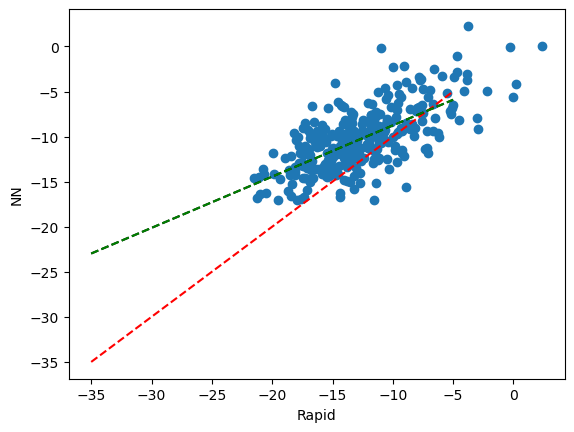

In [46]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)
# plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values)
plt.xlabel('Rapid')
plt.ylabel('NN')
plt.plot([-35, -5], [-35, -5], 'r--')

from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), transport.values.reshape(-1, 1))
in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'k--')
# lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values.reshape(-1, 1))
in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'g--')

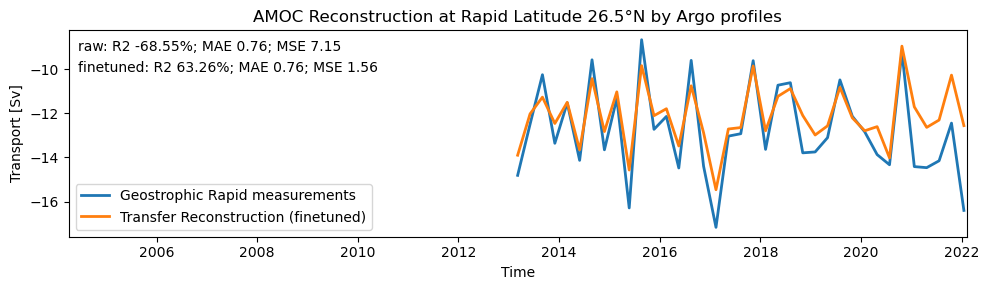

In [69]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

# calc = t_merged_argo_2000.sel(time = transport.time, method = 'nearest')
# ax.plot(calc.time, calc.values, label = 'Geostrohphic calculation from Argos', alpha = .5, color = 'black')
rapid = t_umo_obs.sel(time = transport.time, method = 'nearest')

transport_t = transport.resample(time = '90D').mean()
rapid_t = rapid.resample(time = '90D').mean()
transport_t_fine = transport_finetuned.resample(time = '90D').mean() # - (transport_t - rapid_t).dv_dz_times_X.mean()

# ax.plot(transport_orig.time, transport_orig.values, label = 'Neural Network (pretrained on VIKING20X)', linewidth = 2, zorder = 20)

# ax.plot(transport_t.time, transport_t.values , label = 'Transfer Reconstruction', linewidth = 2, zorder = 20)
ax.plot(rapid_t.time, rapid_t.dv_dz_times_X.values, label = 'Geostrophic Rapid measurements', linewidth = 2)
ax.plot(transport_t_fine.time, transport_t_fine.values , label = 'Transfer Reconstruction (finetuned)', linewidth = 2, zorder = 20)
# ax.plot(transport_t.time, transport_t.values + (rapid_t.dv_dz_times_X -transport_t).mean().values, label = 'Neural Network (finetuned)', linewidth = 2, zorder = 20)
# ax.plot(transport_raw_trained.time, transport_raw_trained.values, label = 'Neural Network (not pretrained)', linewidth = 2, zorder = 20)
ax.set_xlim(train_y.time.min().values, test_y.time.max().values)
plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')

plt.text(0.01, 0.9, f'raw: R2 {r2_score(rapid_t.sel(time = transport_t.time, method = "nearest").dv_dz_times_X.values, transport_t.values)*100:.2f}%; MAE {mae_error:.2f}; MSE {mean_squared_error(rapid_t.sel(time = transport_t.time, method = "nearest").dv_dz_times_X.values, transport_t.values):.2f}', transform=ax.transAxes)

plt.text(0.01, 0.8, f'finetuned: R2 {r2_score(rapid_t.sel(time = transport_t_fine.time, method = "nearest").dv_dz_times_X.values, transport_t_fine.values)*100:.2f}%; MAE {mae_error:.2f}; MSE {mean_squared_error(rapid_t.sel(time = transport_t_fine.time, method = "nearest").dv_dz_times_X.values, transport_t_fine.values):.2f}', transform=ax.transAxes)



fig.tight_layout()


# plt.savefig('../rapid-geostrophic-reconstruction/argo_nn_reconstruction_obs.png')


# mae_error = mean_absolute_error(rapid_t.dv_dz_times_X.values, transport_t.values)

# print(f'R2: {r2_score(rapid_t.dv_dz_times_X.values, transport_t.values)}')
# print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvemqent percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
# print(f'MSE: {mean_squared_error(rapid_t.dv_dz_times_X.values, transport_t.values)}')

plt.savefig(experiment_path / 'transfer_reconstruction_test_predictions_raw.png')

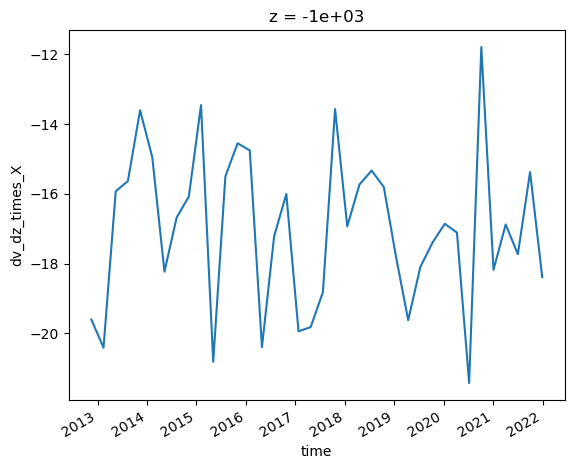

In [78]:
tendays = xr.open_dataset(dataset_path / '4800m_ref' / 't_umo_obs.nc').dv_dz_times_X.sel(time = slice('2013-01-01', None))
ninetydays = xr.open_dataset(Path(str(dataset_path).replace('10', '90'))/ ref_folder / 't_umo_obs.nc').dv_dz_times_X


# tendays = tendays.sel(time = slice('2004', '2019'))
# ninetydays = ninetydays.sel(time = slice('2004', '2019'))

# tendays.plot()
# ninetydays.plot()
# t_umo_10days.dv_dz_times_X.plot()


# t_umo_10days.dv_dz_times_X.plot()

# tendays.groupby(tendays.time.dt.floor('10D')).mean().rename({'floor': 'time'}).plot()
tendays.groupby(tendays.time.dt.floor('90D')).mean().rename({'floor': 'time'}).plot()

# t_umo_10days.resample(time = '90D').mean().dv_dz_times_X.plot()

In [49]:


transport_cleared = transport_t + (rapid_t.dv_dz_times_X -transport_t).mean()


mae_error = mean_absolute_error(rapid_t.sel(time = transport_cleared.time, method = "nearest").dv_dz_times_X.values, transport_cleared.values)

print(f'R2: {r2_score(rapid_t.sel(time = transport_cleared.time, method = "nearest").dv_dz_times_X.values, transport_cleared.values)}')
print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvement percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
print(f'MSE: {mean_squared_error(rapid_t.sel(time = transport_cleared.time, method = "nearest").dv_dz_times_X.values, transport_cleared.values)}')

R2: 0.7506570252537803
MAE: 0.7581788392213692; const MAE 3.438887928716976  improvement percentage:  77.95%
MSE: 1.057405294240197


In [33]:
# transport_t_all = transport_t

In [34]:
transport_t_all.plot()
transport_t.plot()

NameError: name 'transport_t_all' is not defined

In [ ]:
(rapid_t.dv_dz_times_X.values - transport_t.values).mean()

-2.7342932725290656

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


Text(0, 0.5, 'variance temperature')

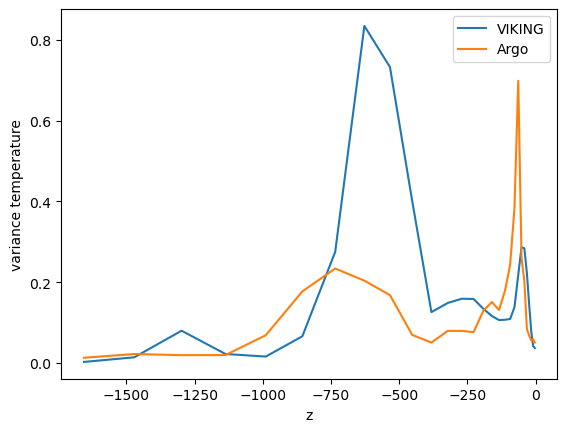

In [ ]:
# After 2019 there is a large drift in the model temperatue therefore we select only the prior years.
a = ds_argo_merged_sim.where(ds_argo_merged_sim.z > -2000, drop = True).sel(time = ds_argo_merged_10days.time).sel(time = slice(None, '2019-01-01')).stack({'profile': ['time', 'pos']})

# salinity larger than 25 takes only valid measurment points as some are filled with zeros. 
a.where(a.profile_mask.any('z'), drop = True).temperature.where(a.salinity > 25).diff('z').var('profile').plot(label = 'VIKING')


b = ds_argo_merged_10days.sel(time = slice(None, '2019-01-01')).stack({'profile': ['time', 'pos']})

b.where(b.profile_mask.any('z'), drop = True).temperature.where(b.salinity > 25).diff('z').var('profile').plot(label = 'Argo')
plt.legend()

plt.ylabel('variance temperature')

In [72]:
dataset_path

PosixPath('../rapid-geostrophic-reconstruction/datasets/smoothing_10_days/argo_after_2012/base_sample')